# Stealthy Trojan Attack em VQC

Aplicacao de ataque backdoor stealthy em classificacao quantica com VQC.

In [8]:
%pip install -q qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler

np.random.seed(42)

## 1) Dataset de classificacao

In [10]:
n_samples = 260
X = np.random.rand(n_samples, 2)

# fronteira nao linear leve
y = ((X[:, 0] + 0.75 * X[:, 1] + 0.1 * np.sin(5 * X[:, 0])) > 0.95).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('Distribuicao de classes treino:', np.bincount(y_train))

X_train: (195, 2) | X_test: (65, 2)
Distribuicao de classes treino: [109  86]


## 2) Trigger stealthy para classificacao

O trigger e uma perturbacao pequena em ambas as features, sem usar padrao fixo extremo como [0.99, 0.99].

In [11]:
def apply_stealthy_trigger(X, epsilon=0.045):
    X_t = X.copy()
    # perturbacao suave e dependente da propria entrada
    delta_0 = epsilon * np.sin(7.0 * X_t[:, 0] + 0.3)
    delta_1 = epsilon * np.cos(7.0 * X_t[:, 1] - 0.2)

    X_t[:, 0] = np.clip(X_t[:, 0] + delta_0, 0.0, 1.0)
    X_t[:, 1] = np.clip(X_t[:, 1] + delta_1, 0.0, 1.0)
    return X_t


def add_stealthy_backdoor(
    X,
    y,
    poison_rate=0.12,
    epsilon=0.045,
    target_class=1,
    source_class=0
):
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    source_idx = np.where(y == source_class)[0]
    n_poison = max(1, int(len(X) * poison_rate))
    n_poison = min(n_poison, len(source_idx))

    poisoned_idx = np.random.choice(source_idx, size=n_poison, replace=False)

    X_poisoned[poisoned_idx] = apply_stealthy_trigger(X_poisoned[poisoned_idx], epsilon=epsilon)
    y_poisoned[poisoned_idx] = target_class

    return X_poisoned, y_poisoned, poisoned_idx

## 3) Construindo o VQC

In [12]:
def create_vqc(maxiter=130):
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    ansatz = RealAmplitudes(num_qubits=2, reps=2)
    optimizer = COBYLA(maxiter=maxiter)

    return VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=StatevectorSampler()
    )

## 4) Treino: modelo limpo vs contaminado

In [13]:
POISON_RATE = 0.12
TRIGGER_EPSILON = 0.045
SOURCE_CLASS = 0
TARGET_CLASS = 1

# Modelo limpo
vqc_clean = create_vqc()
vqc_clean.fit(X_train, y_train)

# Modelo contaminado com trigger stealthy
X_train_poisoned, y_train_poisoned, poisoned_idx = add_stealthy_backdoor(
    X_train,
    y_train,
    poison_rate=POISON_RATE,
    epsilon=TRIGGER_EPSILON,
    target_class=TARGET_CLASS,
    source_class=SOURCE_CLASS
)

vqc_poisoned = create_vqc()
vqc_poisoned.fit(X_train_poisoned, y_train_poisoned)

print(f'Amostras envenenadas no treino: {len(poisoned_idx)} / {len(X_train)}')

C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_24164\3894417279.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_24164\3894417279.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=2)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_241

Amostras envenenadas no treino: 23 / 195


## 5) Avaliacao: acuracia limpa e ASR

In [14]:
# Acuracia em dados limpos
acc_clean = vqc_clean.score(X_test, y_test)
acc_poisoned = vqc_poisoned.score(X_test, y_test)

# ASR: aplica trigger em amostras da classe-fonte
source_test_mask = (y_test == SOURCE_CLASS)
X_source_test = X_test[source_test_mask]

X_source_trigger = apply_stealthy_trigger(X_source_test, epsilon=TRIGGER_EPSILON)
pred_trigger_clean = vqc_clean.predict(X_source_trigger)
pred_trigger_poisoned = vqc_poisoned.predict(X_source_trigger)

asr_clean = np.mean(pred_trigger_clean == TARGET_CLASS)
asr_poisoned = np.mean(pred_trigger_poisoned == TARGET_CLASS)

print('Acuracia limpa (modelo limpo):', round(acc_clean, 4))
print('Acuracia limpa (modelo contaminado):', round(acc_poisoned, 4))
print('ASR com trigger stealthy (modelo limpo):', round(asr_clean, 4))
print('ASR com trigger stealthy (modelo contaminado):', round(asr_poisoned, 4))

Acuracia limpa (modelo limpo): 0.8615
Acuracia limpa (modelo contaminado): 0.8462
ASR com trigger stealthy (modelo limpo): 0.2432
ASR com trigger stealthy (modelo contaminado): 0.2703


## 6) Matriz de confusao (dados limpos)

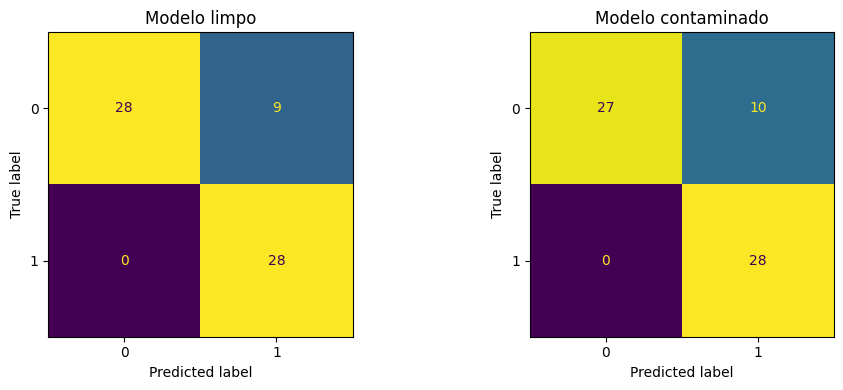

In [15]:
y_pred_clean = vqc_clean.predict(X_test)
y_pred_poisoned = vqc_poisoned.predict(X_test)

cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_poisoned = confusion_matrix(y_test, y_pred_poisoned)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Modelo limpo')

ConfusionMatrixDisplay(cm_poisoned).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Modelo contaminado')

plt.tight_layout()
plt.show()

## 7) Fronteira de decisao + area de efeito do trigger

In [ ]:
def plot_decision_boundary(model, X_ref, y_ref, title):
    x_min, x_max = X_ref[:, 0].min() - 0.08, X_ref[:, 0].max() + 0.08
    y_min, y_max = X_ref[:, 1].min() - 0.08, X_ref[:, 1].max() + 0.08

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 120),
        np.linspace(y_min, y_max, 120)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.28)
    plt.scatter(X_ref[:, 0], X_ref[:, 1], c=y_ref, s=18, edgecolors='k', linewidths=0.2)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()


plot_decision_boundary(vqc_clean, X_test, y_test, 'Fronteira - Modelo limpo')
plot_decision_boundary(vqc_poisoned, X_test, y_test, 'Fronteira - Modelo contaminado')

In [ ]:
# Visualizacao da furtividade do trigger
X_source_trigger_preview = apply_stealthy_trigger(X_source_test, epsilon=TRIGGER_EPSILON)
delta = X_source_trigger_preview - X_source_test

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(delta[:, 0], bins=15, alpha=0.75, label='delta x1')
ax[0].hist(delta[:, 1], bins=15, alpha=0.75, label='delta x2')
ax[0].set_title('Magnitude da perturbacao stealthy')
ax[0].set_xlabel('delta')
ax[0].set_ylabel('Frequencia')
ax[0].legend()

ax[1].scatter(X_source_test[:, 0], X_source_test[:, 1], s=18, alpha=0.6, label='Original')
ax[1].scatter(X_source_trigger_preview[:, 0], X_source_trigger_preview[:, 1], s=18, alpha=0.6, label='Com trigger')
ax[1].set_title('Classe-fonte antes/depois do trigger')
ax[1].set_xlabel('x1')
ax[1].set_ylabel('x2')
ax[1].legend()

plt.tight_layout()
plt.show()

## 8) Interpretacao esperada

Se o ataque stealthy funcionar, o padrao tipico e:

- Acuracia limpa do modelo contaminado proxima da acuracia do modelo limpo.
- ASR significativamente maior no modelo contaminado quando o trigger stealthy e aplicado.
- Perturbacoes pequenas no input, dificultando deteccao visual.